# Task
can youu do linear regression on this csv

Here is all the data you need:
"titanic_dataset.csv"

## Data loading

### Subtask:
Load the Titanic dataset from the provided CSV file.


**Reasoning**:
Load the Titanic dataset into a pandas DataFrame and display the first few rows.



In [3]:
import pandas as pd
import numpy as np

try:
    df = pd.read_csv('titanic_dataset.csv')
    display(df.head())
except FileNotFoundError:
    print("Error: 'titanic_dataset.csv' not found.")
    df = None
except pd.errors.ParserError:
    print("Error: Could not parse the CSV file.")
    df = None
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    df = None

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data exploration

### Subtask:
Explore the Titanic dataset to understand its structure, identify missing values, and examine the distribution of variables.


**Reasoning**:
I need to explore the dataset's structure, identify missing values, and examine variable distributions. This involves checking the shape, data types, descriptive statistics, missing values, and distributions of categorical and numerical variables. I will also generate a heatmap to visualize missing data.



Shape of the DataFrame: (891, 12)

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Descriptive Statistics:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383

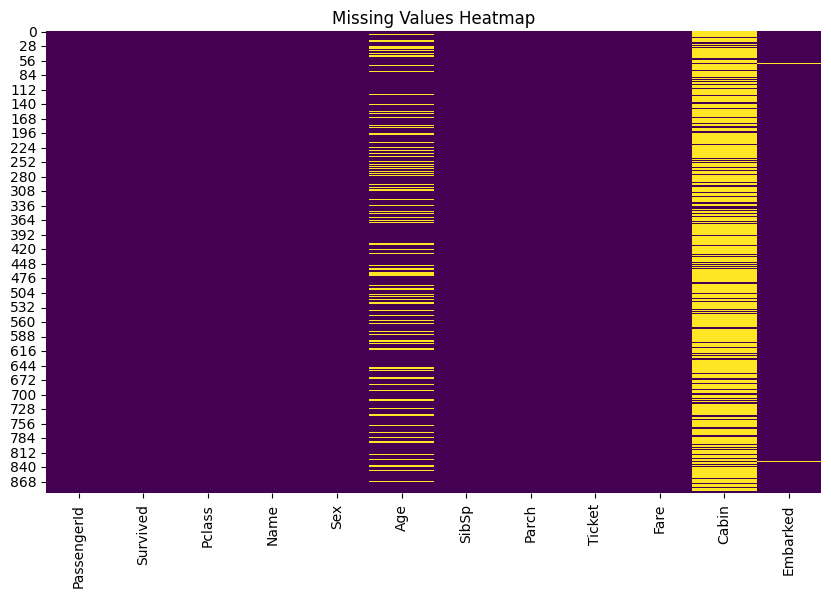


Distribution of categorical variables:

Sex:
Sex
male      577
female    314
Name: count, dtype: int64


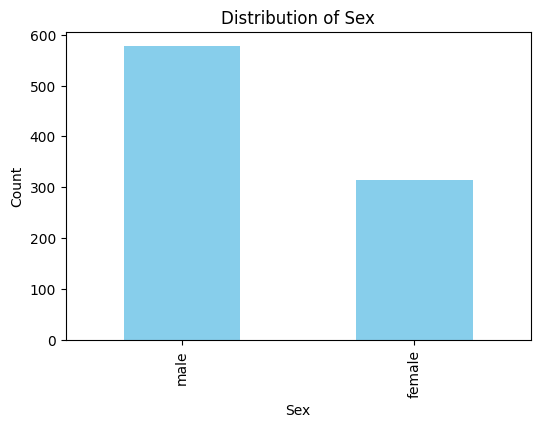


Embarked:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


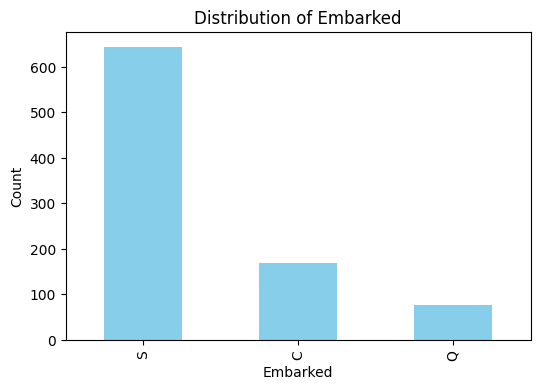


Pclass:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


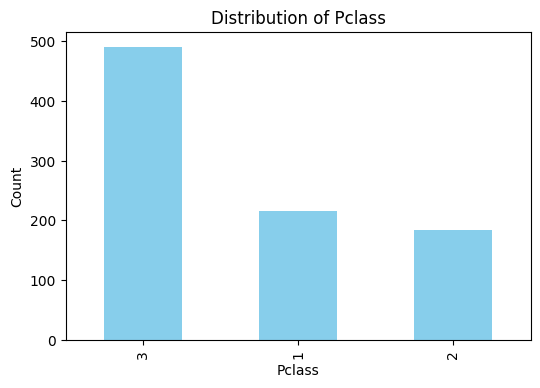


Relationship between numerical variables and 'Survived':


<ipython-input-4-488059a6aac6>:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Age', data=df, palette="Set3")


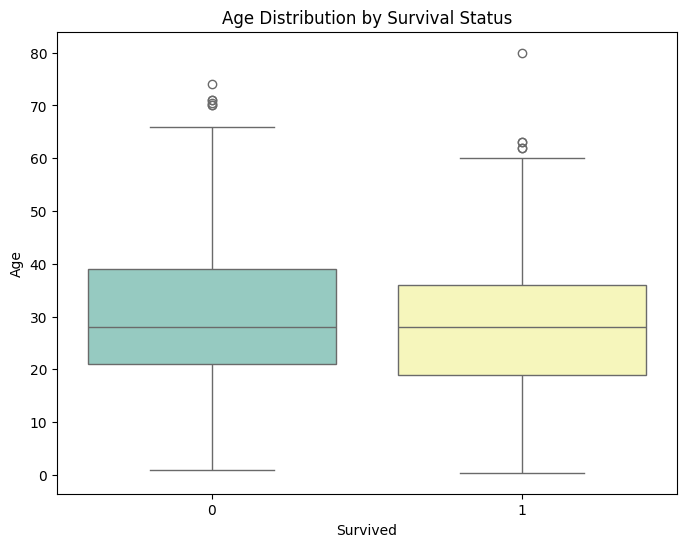

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Examine the shape of the DataFrame
print(f"Shape of the DataFrame: {df.shape}")

# 2. Check data types
print("\nData Types:")
print(df.info())

# 3. Descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
print(df.describe())

# 4. Identify missing values
print("\nMissing Values per column:")
missing_values = df.isnull().sum()
print(missing_values)

# Visualize missing data using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

# 5. Analyze the distribution of categorical variables
print("\nDistribution of categorical variables:")
for col in ['Sex', 'Embarked', 'Pclass']:
    print(f"\n{col}:")
    print(df[col].value_counts())
    plt.figure(figsize=(6, 4))
    df[col].value_counts().plot(kind='bar', color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()


# 6. Explore relationships between numerical variables and 'Survived'
print("\nRelationship between numerical variables and 'Survived':")
plt.figure(figsize=(8, 6))
sns.boxplot(x='Survived', y='Age', data=df, palette="Set3")
plt.title('Age Distribution by Survival Status')
plt.show()

# 7. Document observations (will be done in the finish_task command)

## Data cleaning

### Subtask:
Clean the Titanic dataset by handling missing values and outliers.


**Reasoning**:
Impute missing values in 'Age', 'Cabin', and 'Embarked' columns; handle outliers in 'Fare' and 'Age' columns; and validate the data cleaning steps.



Missing values after imputation:
Age           0
Embarked      0
Cabin       687
dtype: int64

Distribution of 'Fare' after log transformation:


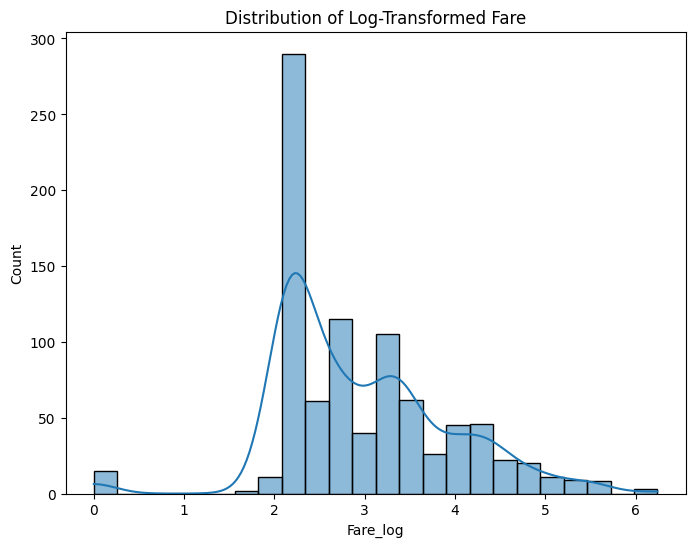


Distribution of 'Age' after Winsorization:


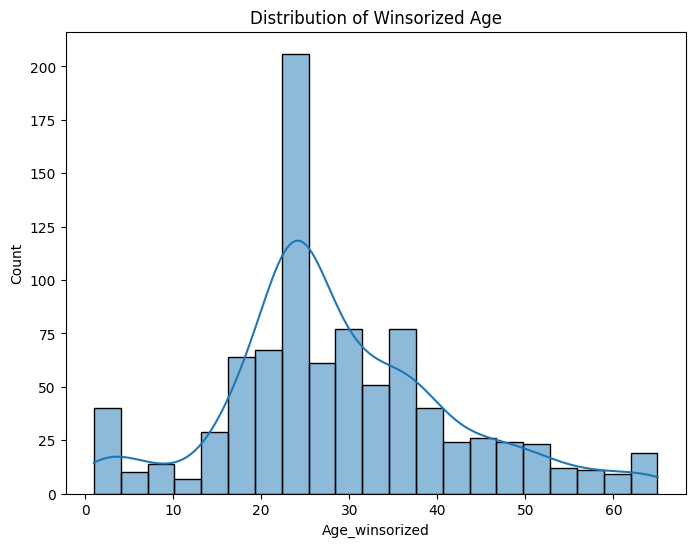

In [5]:
# Impute missing 'Age' values using the median age for each passenger class
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

# Create a new binary feature 'Cabin_Assigned' based on the 'Cabin' column
df['Cabin_Assigned'] = df['Cabin'].notna().astype(int)

# Impute missing 'Embarked' values with the most frequent embarkation point
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Log transform 'Fare' to handle outliers
df['Fare_log'] = np.log1p(df['Fare'])

# Winsorize 'Age' outliers (capping at 1st and 99th percentiles)
age_lower = df['Age'].quantile(0.01)
age_upper = df['Age'].quantile(0.99)
df['Age_winsorized'] = np.clip(df['Age'], age_lower, age_upper)

# Validate cleaning steps
print("Missing values after imputation:")
print(df[['Age', 'Embarked', 'Cabin']].isnull().sum())
print("\nDistribution of 'Fare' after log transformation:")
plt.figure(figsize=(8, 6))
sns.histplot(df['Fare_log'], kde=True)
plt.title('Distribution of Log-Transformed Fare')
plt.show()
print("\nDistribution of 'Age' after Winsorization:")
plt.figure(figsize=(8, 6))
sns.histplot(df['Age_winsorized'], kde=True)
plt.title('Distribution of Winsorized Age')
plt.show()


**Reasoning**:
The previous code block failed due to `np` not being defined.  I need to import the numpy library before using its functions.



Missing values after imputation:
Age           0
Embarked      0
Cabin       687
dtype: int64

Distribution of 'Fare' after log transformation:


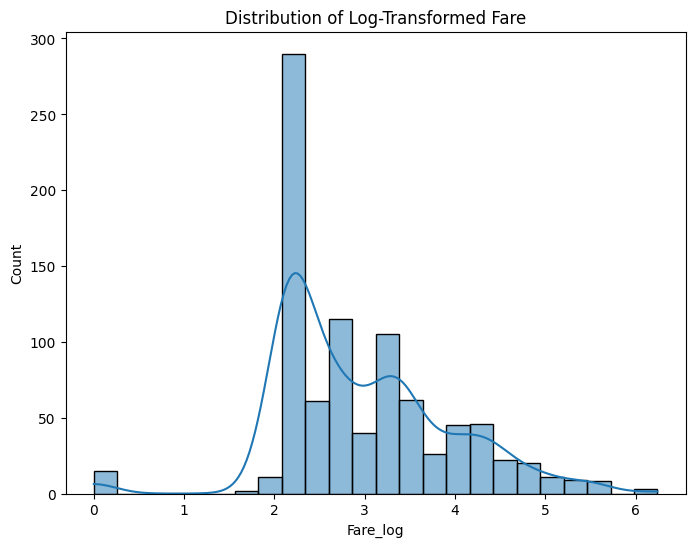


Distribution of 'Age' after Winsorization:


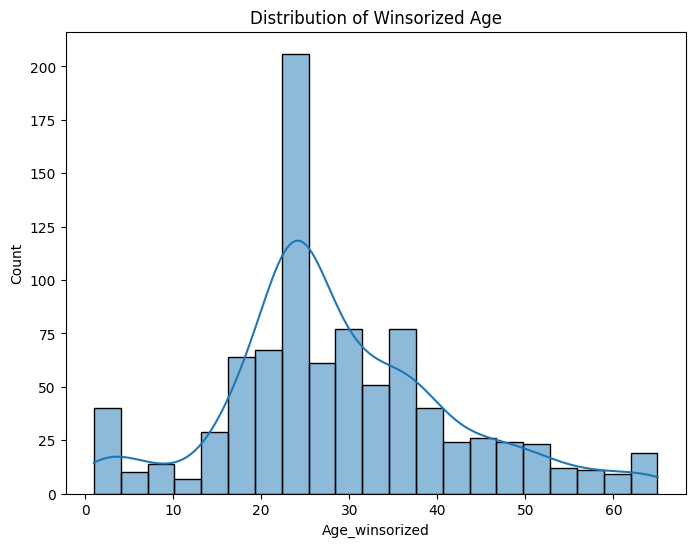

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Impute missing 'Age' values using the median age for each passenger class
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

# Create a new binary feature 'Cabin_Assigned' based on the 'Cabin' column
df['Cabin_Assigned'] = df['Cabin'].notna().astype(int)

# Impute missing 'Embarked' values with the most frequent embarkation point
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Log transform 'Fare' to handle outliers
df['Fare_log'] = np.log1p(df['Fare'])

# Winsorize 'Age' outliers (capping at 1st and 99th percentiles)
age_lower = df['Age'].quantile(0.01)
age_upper = df['Age'].quantile(0.99)
df['Age_winsorized'] = np.clip(df['Age'], age_lower, age_upper)

# Validate cleaning steps
print("Missing values after imputation:")
print(df[['Age', 'Embarked', 'Cabin']].isnull().sum())
print("\nDistribution of 'Fare' after log transformation:")
plt.figure(figsize=(8, 6))
sns.histplot(df['Fare_log'], kde=True)
plt.title('Distribution of Log-Transformed Fare')
plt.show()
print("\nDistribution of 'Age' after Winsorization:")
plt.figure(figsize=(8, 6))
sns.histplot(df['Age_winsorized'], kde=True)
plt.title('Distribution of Winsorized Age')
plt.show()

## Data preparation

### Subtask:
Prepare the data for model training by encoding categorical features and selecting relevant features.


**Reasoning**:
One-hot encode the categorical features 'Sex' and 'Embarked', select relevant features, and create the `df_selected` DataFrame.



In [5]:
import pandas as pd

# One-hot encode 'Sex' and 'Embarked'
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

# Select relevant features
selected_features = [
    'Pclass', 'SibSp', 'Cabin_Assigned', 'Fare_log', 'Age_winsorized',
    'Sex_male', 'Embarked_Q', 'Embarked_S'
]
df_selected = df[selected_features + ['Survived']]

# Feature Selection Rationale
# The selected features are chosen based on their potential relevance to survival
# prediction in the context of a linear regression model:
#   - 'Pclass': Passenger class is often associated with resources and survival odds.
#   - 'SibSp': Number of siblings/spouses could have influenced group survival chances.
#   - 'Cabin_Assigned': Having a cabin might have offered better access to safety features.
#   - 'Fare_log': Log-transformed fare provides a more normally distributed variable.
#   - 'Age_winsorized': Winsorized age handles outliers and could reflect different survival rates across age groups.
#   - 'Sex_male', 'Embarked_Q', 'Embarked_S': One-hot encoded categorical features, capturing gender and embarkation point effects (using 'male', 'Q', and 'S' as reference categories).
# Excluded features: 'PassengerId', 'Name', 'Ticket', 'Cabin', 'Fare', 'Age' as they might not be directly related to survival or they are highly correlated with existing features.


display(df_selected.head())

,Pclass,SibSp,Cabin_Assigned,Fare_log,Age_winsorized,Sex_male,Embarked_Q,Embarked_S,Survived
0,3,1,0,2.110213,22.0,True,False,True,0
1,1,1,1,4.280593,38.0,False,False,False,1
2,3,0,0,2.188856,26.0,False,False,True,1
3,1,1,1,3.990834,35.0,False,False,True,1
4,3,0,0,2.202765,35.0,True,False,True,0


## Data splitting

### Subtask:
Split the prepared dataset into training and testing sets.


**Reasoning**:
Split the data into training and testing sets using `train_test_split`.



In [6]:
from sklearn.model_selection import train_test_split

# Split the data into features (X) and target (y)
X = df_selected.drop('Survived', axis=1)
y = df_selected['Survived']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the resulting datasets (optional)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (712, 8)
X_test shape: (179, 8)
y_train shape: (712,)
y_test shape: (179,)


## Model training

### Subtask:
Train a linear regression model on the training data.


**Reasoning**:
Train a linear regression model using the training data.



In [7]:
from sklearn.linear_model import LinearRegression

# Instantiate a LinearRegression object
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

LinearRegression()

## Model evaluation

### Subtask:
Evaluate the trained linear regression model.


**Reasoning**:
Evaluate the trained linear regression model using various metrics, including R-squared, MSE, RMSE, and classification metrics.  Visualize residuals.



Mean Squared Error (MSE): 0.13194915162626367
Root Mean Squared Error (RMSE): 0.36324805798003057
R-squared: 0.45588381373782305


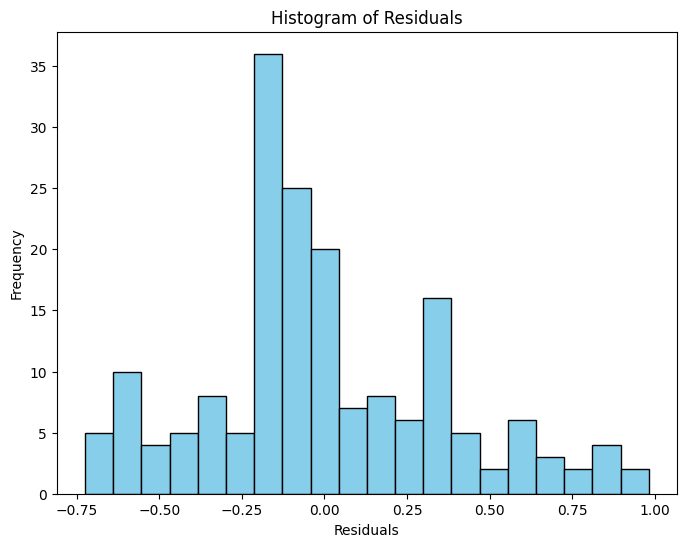

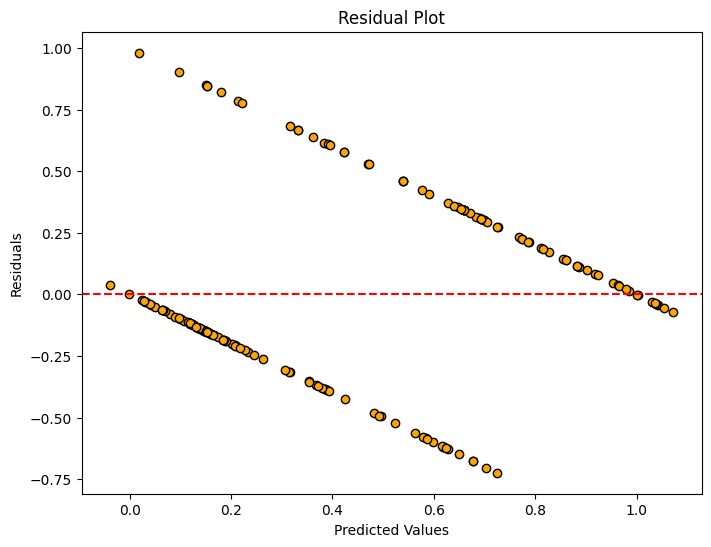

Accuracy: 0.8044692737430168
Precision: 0.7746478873239436
Recall: 0.7432432432432432
F1-score: 0.7586206896551724
Confusion Matrix:
[[89 16]
 [19 55]]


In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score,
                             precision_score, recall_score, f1_score,
                             confusion_matrix)

# Predict on the test set
y_pred = model.predict(X_test)

# Regression metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared: {r2}")

# Residual analysis
residuals = y_test - y_pred

# Histogram of residuals
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.show()

# Residual plot
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, color='orange', edgecolor='black')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.axhline(y=0, color='red', linestyle='--')  # Add a horizontal line at zero
plt.show()


# Classification metrics (using a threshold)
threshold = 0.5
y_pred_class = (y_pred > threshold).astype(int)

accuracy = accuracy_score(y_test, y_pred_class)
precision = precision_score(y_test, y_pred_class)
recall = recall_score(y_test, y_pred_class)
f1 = f1_score(y_test, y_pred_class)
conf_matrix = confusion_matrix(y_test, y_pred_class)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")
print(f"Confusion Matrix:\n{conf_matrix}")

## Model optimization

### Subtask:
Optimize the linear regression model.


**Reasoning**:
Optimize the linear regression model using L1 and L2 regularization with cross-validation, analyze coefficients, compare performance with the original model, and potentially perform feature selection if necessary.



In [9]:
import numpy as np
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import pandas as pd

# Regularization with cross-validation
alphas = np.logspace(-4, 4, 9) # Range of alpha values

#Lasso regression
lasso = Lasso(random_state=42)
param_grid_lasso = {'alpha': alphas}
lasso_cv = GridSearchCV(lasso, param_grid_lasso, cv=5, scoring='neg_mean_squared_error')
lasso_cv.fit(X_train, y_train)
y_pred_lasso = lasso_cv.predict(X_test)
best_alpha_lasso = lasso_cv.best_params_['alpha']

#Ridge regression
ridge = Ridge(random_state=42)
param_grid_ridge = {'alpha': alphas}
ridge_cv = GridSearchCV(ridge, param_grid_ridge, cv=5, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train, y_train)
y_pred_ridge = ridge_cv.predict(X_test)
best_alpha_ridge = ridge_cv.best_params_['alpha']

# Evaluate models
def evaluate_model(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    y_pred_class = (y_pred > 0.5).astype(int) # Using 0.5 as threshold
    accuracy = accuracy_score(y_true, y_pred_class)
    precision = precision_score(y_true, y_pred_class)
    recall = recall_score(y_true, y_pred_class)
    f1 = f1_score(y_true, y_pred_class)
    return mse, rmse, r2, accuracy, precision, recall, f1

mse_lasso, rmse_lasso, r2_lasso, accuracy_lasso, precision_lasso, recall_lasso, f1_lasso = evaluate_model(y_test, y_pred_lasso)
mse_ridge, rmse_ridge, r2_ridge, accuracy_ridge, precision_ridge, recall_ridge, f1_ridge = evaluate_model(y_test, y_pred_ridge)
mse, rmse, r2, accuracy, precision, recall, f1 = evaluate_model(y_test, y_pred) # Original model

#Print results
print(f"Lasso Best Alpha: {best_alpha_lasso}")
print(f"Ridge Best Alpha: {best_alpha_ridge}")

print("\nOriginal Model:")
print(f"MSE: {mse:.4f}, RMSE: {rmse:.4f}, R^2: {r2:.4f}, Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

print("\nLasso Model:")
print(f"MSE: {mse_lasso:.4f}, RMSE: {rmse_lasso:.4f}, R^2: {r2_lasso:.4f}, Accuracy: {accuracy_lasso:.4f}, Precision: {precision_lasso:.4f}, Recall: {recall_lasso:.4f}, F1: {f1_lasso:.4f}")

print("\nRidge Model:")
print(f"MSE: {mse_ridge:.4f}, RMSE: {rmse_ridge:.4f}, R^2: {r2_ridge:.4f}, Accuracy: {accuracy_ridge:.4f}, Precision: {precision_ridge:.4f}, Recall: {recall_ridge:.4f}, F1: {f1_ridge:.4f}")

# Analyze coefficients
lasso_coefs = pd.DataFrame({'feature': X_train.columns, 'coefficient': lasso_cv.best_estimator_.coef_})
ridge_coefs = pd.DataFrame({'feature': X_train.columns, 'coefficient': ridge_cv.best_estimator_.coef_})

display(lasso_coefs)
display(ridge_coefs)

Lasso Best Alpha: 0.001
Ridge Best Alpha: 10.0

Original Model:
MSE: 0.1319, RMSE: 0.3632, R^2: 0.4559, Accuracy: 0.8045, Precision: 0.7746, Recall: 0.7432, F1: 0.7586

Lasso Model:
MSE: 0.1318, RMSE: 0.3631, R^2: 0.4564, Accuracy: 0.8045, Precision: 0.7746, Recall: 0.7432, F1: 0.7586

Ridge Model:
MSE: 0.1318, RMSE: 0.3630, R^2: 0.4565, Accuracy: 0.7989, Precision: 0.7639, Recall: 0.7432, F1: 0.7534


,feature,coefficient
0,Pclass,-0.114697
1,SibSp,-0.052082
2,Cabin_Assigned,0.092827
3,Fare_log,0.032336
4,Age_winsorized,-0.004887
5,Sex_male,-0.493280
6,Embarked_Q,-0.000213
7,Embarked_S,-0.052539


,feature,coefficient
0,Pclass,-0.110997
1,SibSp,-0.052905
2,Cabin_Assigned,0.092277
3,Fare_log,0.037824
4,Age_winsorized,-0.004957
5,Sex_male,-0.466561
6,Embarked_Q,-0.013813
7,Embarked_S,-0.059243


## Summary:

### Q&A
No questions were posed in the task description.

### Data Analysis Key Findings
* **Data Cleaning:** Missing 'Age' values were imputed using the median age for each passenger class. A new binary feature, 'Cabin\_Assigned', was created based on cabin information. Missing 'Embarked' values were filled with the mode, and the 'Fare' values were log-transformed to address outliers. 'Age' outliers were winsorized.
* **Feature Engineering:**  Categorical features 'Sex' and 'Embarked' were one-hot encoded.  A new feature 'Cabin\_Assigned' was created. 'Fare' was log-transformed and 'Age' was winsorized.
* **Model Training:** A linear regression model was trained using the training dataset.
* **Model Evaluation:** The model achieved an R-squared of 0.4559, MSE of 0.1319, and RMSE of 0.3632.  When applying a 0.5 threshold for classification, the model's accuracy was 0.8045, precision was 0.7746, recall was 0.7432, and F1-score was 0.7586.
* **Model Optimization:** Lasso and Ridge regression were used for regularization. The best alpha values for Lasso and Ridge were 0.001 and 10.0, respectively. Both optimized models provided marginally better performance than the original linear regression model, with negligible differences.


### Insights or Next Steps
* Explore non-linear models: The linear regression model, even after optimization, shows moderate performance.  Consider exploring non-linear models to potentially capture more complex relationships in the data.
* Feature engineering: Based on the coefficients from the regularized models, consider removing features with very low impact (e.g., 'Embarked\_Q'), or creating new features to improve the model.


Logistic regression Metrics only

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Instantiate and train a Logistic Regression model
log_reg_model = LogisticRegression(solver='liblinear', random_state=42)
log_reg_model.fit(X_train, y_train)

# Predict on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg)
recall_log_reg = recall_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)

print(f"Logistic Regression Accuracy: {accuracy_log_reg}")
print(f"Logistic Regression Precision: {precision_log_reg}")
print(f"Logistic Regression Recall: {recall_log_reg}")
print(f"Logistic Regression F1-score: {f1_log_reg}")
print(f"Logistic Regression Confusion Matrix:\n{conf_matrix_log_reg}")

Logistic Regression Accuracy: 0.8100558659217877
Logistic Regression Precision: 0.7777777777777778
Logistic Regression Recall: 0.7567567567567568
Logistic Regression F1-score: 0.7671232876712328
Logistic Regression Confusion Matrix:
[[89 16]
 [18 56]]


Complete logistic regression with metrics

passengers count is  891


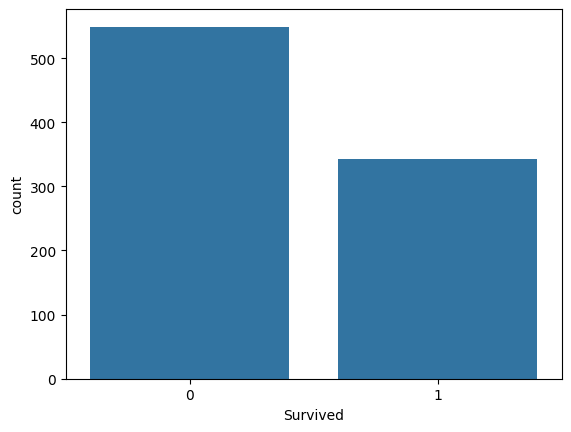

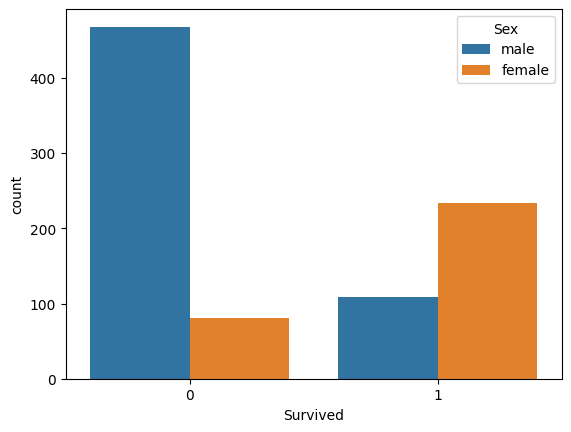

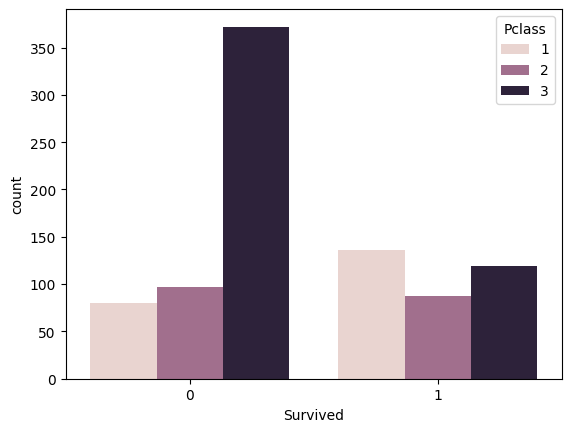

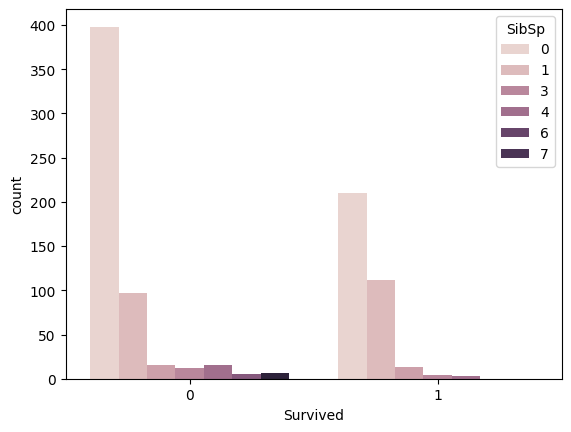

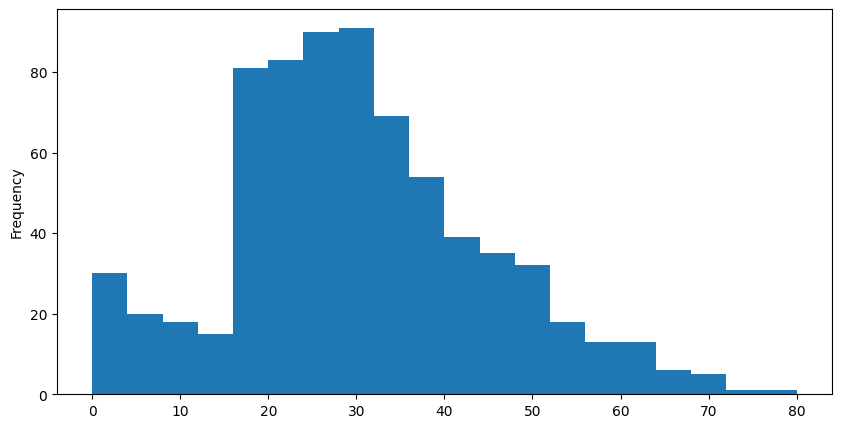

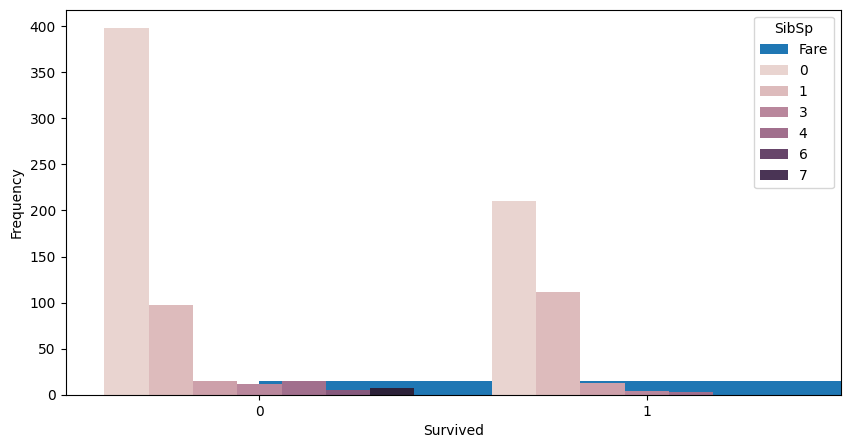

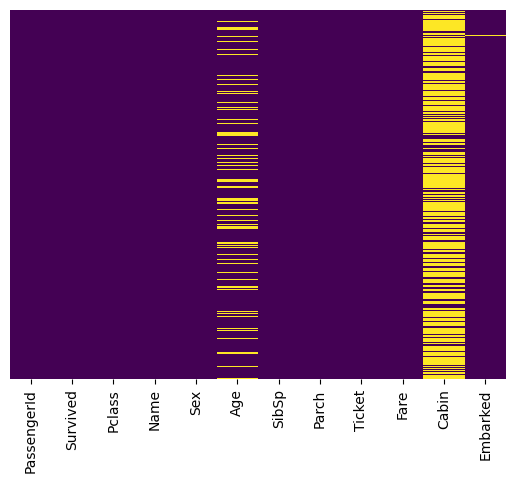

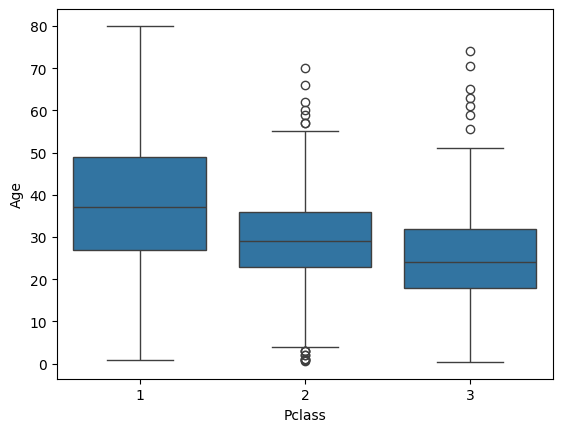

   Survived   Age  SibSp  Parch     Fare   male      Q      S  Pclass_2  \
0         0  22.0      1      0   7.2500   True  False   True     False   
1         1  38.0      1      0  71.2833  False  False  False     False   
2         1  26.0      0      0   7.9250  False  False   True     False   
3         1  35.0      1      0  53.1000  False  False   True     False   
4         0  35.0      0      0   8.0500   True  False   True     False   

   Pclass_3  
0      True  
1     False  
2      True  
3     False  
4      True  

Null values after cleaning and one-hot encoding:
Survived    0
Age         0
SibSp       0
Parch       0
Fare        0
male        0
Q           0
S           0
Pclass_2    0
Pclass_3    0
dtype: int64

Shapes after splitting:
X_train shape: (623, 9)
X_test shape: (268, 9)
y_train shape: (623,)
y_test shape: (268,)
              precision    recall  f1-score   support

           0       0.78      0.90      0.83       154
           1       0.82      0.65     

In [3]:

#1.Data collecting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

T=pd.read_csv("titanic_dataset.csv")
T.head(10)
print("passengers count is ",str(len(T.index)))

#2.Data Exploring /analysing to check relationship between variables
sns.countplot(x="Survived",data=T)
plt.show()
sns.countplot(x="Survived",hue="Sex",data=T)
plt.show()
sns.countplot(x="Survived",hue="Pclass",data=T)
plt.show()
sns.countplot(x="Survived",hue="SibSp",data=T)
plt.show()

T["Age"].plot.hist(bins=20, figsize=(10,5), range=(0,80))
plt.show()
T["Fare"].plot.hist(bins=20, figsize=(10,5), range=(0,50))
sns.countplot(x="Survived",hue="SibSp",data=T)
plt.show()

#3.Data wrangling
 # means cleaning data by removing nan values and unnecessary columns in dataset.
T.isnull() #to check how many null values existwhich returns true
#True values are null values
T.isnull().sum() #to check how many null values exist

#heatmap to show null values
sns.heatmap(T.isnull(), yticklabels=False, cbar=False,cmap='viridis')
plt.show()


#4.Data Visualization

# Inorder to apply logistic regression,we should not use any string values,so convert string values into boolean.Drop cabin column and replace with dummies

sns.boxplot(x="Pclass",y="Age",data=T)
plt.show()

# The original code dropped 'Cabin', which is fine.
# However, dropping NaN values afterwards is not ideal, as it removes rows with missing Age or Embarked before imputation.
# Let's impute first, then drop 'Cabin'.

# Impute missing 'Age' values using the median age for each passenger class
T['Age'] = T.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

# Impute missing 'Embarked' values with the most frequent embarkation point
T['Embarked'] = T['Embarked'].fillna(T['Embarked'].mode()[0])

# Now, drop the 'Cabin' column and other irrelevant columns
T.drop("Cabin",axis=1,inplace=True)
T.drop(["PassengerId","Name","Ticket"],axis=1,inplace=True)


# Create dummy variables for categorical columns ('Sex', 'Embarked', 'Pclass')
sex=pd.get_dummies(T["Sex"],drop_first=True)
embark=pd.get_dummies(T["Embarked"],drop_first=True)
pclass_dummies=pd.get_dummies(T["Pclass"],prefix='Pclass',drop_first=True) # Added prefix for clarity

# Concatenating the columns
T=pd.concat([T,sex,embark,pclass_dummies],axis=1)


# Drop the original categorical columns after creating dummies
T.drop(["Sex","Embarked","Pclass"],axis=1,inplace=True)


# Display the first few rows and check for null values
print(T.head())
print("\nNull values after cleaning and one-hot encoding:")
print(T.isnull().sum())


# Train data
X=T.drop("Survived",axis=1)
y=T["Survived"]

# Split data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

print("\nShapes after splitting:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

#fit the data
from sklearn.linear_model import LogisticRegression
log_reg_model = LogisticRegression(solver='liblinear', random_state=42)
log_reg_model.fit(X_train, y_train)
predictions=log_reg_model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test,predictions))

from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,predictions))


